In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras import initializers

2025-11-04 22:26:20.166135: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-04 22:26:20.199317: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-04 22:26:21.335635: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Duomenu autorius parase, kad duomenys yra 300x200
IMG_WIDTH = 300
IMG_HEIGHT = 200
N_CLASSES = 3
BATCH_SIZE = 16

In [3]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [4]:
# https://stackoverflow.com/questions/70217561/tensorflow-image-dataset-from-directory-split-to-train-validation-testing

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory ='data/',
    image_size = (IMG_HEIGHT, IMG_WIDTH),
    validation_split = 0.2,
    subset = "training",
    color_mode='rgb',
    seed = 42,
    shuffle = True,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    directory ='data/',
    image_size = (IMG_HEIGHT, IMG_WIDTH),
    validation_split = 0.2,
    subset = "validation",
    color_mode='rgb',
    seed = 42,
    shuffle = True,
    batch_size=BATCH_SIZE
)

val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

Found 2188 files belonging to 3 classes.
Using 1751 files for training.


I0000 00:00:1762287982.294757  203353 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2140 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 2188 files belonging to 3 classes.
Using 437 files for validation.


- Toliau kodas paimtas ir pagal poreikius redaguotas is https://www.tensorflow.org/tutorials/images/classification

In [5]:
class_names = train_ds.class_names

2025-11-04 22:26:25.035250: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


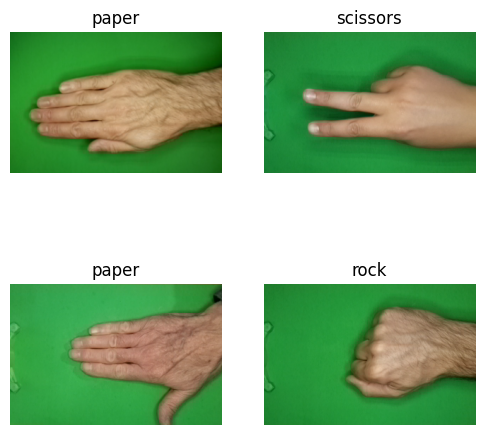

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
for images, labels in train_ds.take(1):
  for i in range(4):
    ax = plt.subplot(2, 2, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))

    plt.title( class_names[ labels[i]] )

    plt.axis("off")

plt.savefig('iliusteracija_data.png', dpi=200)

In [7]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(16, 200, 300, 3)
(16,)


- He incializacija: https://keras.io/api/layers/initializers/#henormal-class ir https://keras.io/api/layers/convolution_layers/convolution2d/
- Sequential keras CNN: https://www.tensorflow.org/tutorials/images/classification#a_basic_keras_model
- BatchNormalization: https://www.datacamp.com/tutorial/batch-normalization-tensorflow

## 1 architektūra

Paprastas konvoliucinis neuroninis tinklas

In [8]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 200, 300, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [9]:
kernel_counts = [16, 32]
kernel_size = 7
pool_filter_size = 3
dropout = 0.25
aktyvacija = "relu"
paslepto_ties_skaicius = 16

model_layers1 = [
    layers.Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3), batch_size=BATCH_SIZE),
    layers.Rescaling(1./255)
]

for kernel_count in kernel_counts:
    model_layers1.extend([
        layers.Conv2D(
            kernel_count, 
            kernel_size,
            padding='same',
            activation=aktyvacija,
            kernel_initializer=initializers.HeNormal()
        ),
        layers.Dropout(dropout),
        layers.BatchNormalization(),
        layers.MaxPool2D((pool_filter_size, pool_filter_size))
    ])

model_layers1.extend([
    layers.Flatten(),
    layers.Dense(paslepto_ties_skaicius, activation='relu'),
    layers.Dense(N_CLASSES, activation="softmax")
])

In [10]:
lr = 1e-5
loss_func = "sparse_categorical_crossentropy"
epochs = 20

model1 = keras.Sequential(model_layers1)
optimizer = keras.optimizers.Adam(learning_rate=lr)

model1.compile(
    optimizer=optimizer,
    loss=loss_func,
    metrics=['accuracy']
)

history1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1
)

Epoch 1/20


2025-11-04 20:11:01.541390: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f7b70006320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-04 20:11:01.541407: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2025-11-04 20:11:01.565953: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-04 20:11:01.715302: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400


  3/110 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.4514 - loss: 1.3474 

I0000 00:00:1762279865.825885  152468 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


110/110 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - accuracy: 0.5911 - loss: 0.9274 - val_accuracy: 0.4695 - val_loss: 1.0150
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.8515 - loss: 0.4004 - val_accuracy: 0.5399 - val_loss: 0.9035
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9195 - loss: 0.2557 - val_accuracy: 0.6056 - val_loss: 0.7539
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9435 - loss: 0.1772 - val_accuracy: 0.7700 - val_loss: 0.5149
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9663 - loss: 0.1364 - val_accuracy: 0.8920 - val_loss: 0.3612
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9743 - loss: 0.1065 - val_accuracy: 0.8779 - val_loss: 0.3240
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9812 - loss: 0.0875 - val_accuracy: 0.9296 - val_loss: 0.2192
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9880 - loss: 0.0691 - val_accuracy: 0.90

In [11]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (16, 300, 200, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (16, 300, 200, 16)     │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (16, 300, 200, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (16, 300, 200, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (16, 100, 66, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (16, 100, 66, 32)      │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (16, 100, 66, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (16, 100, 66, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (16, 33, 22, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (16, 23232)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (16, 16)               │       371,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (16, 3)                │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,198,187 (4.57 MB)

 Trainable params: 399,363 (1.52 MB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 798,728 (3.05 MB)

## 2 architektūra

VGGNet su pakeitimu: daugiau reguliarizacijos

In [12]:
kernel_counts = [64, 128, 256, 256, 512, 512]
kernel_size = 3
pool_filter_size = 3
dropout = 0.25
aktyvacija = "relu"
paslepto_ties_skaicius = 16

model_layers2 = [
    layers.Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3), batch_size=BATCH_SIZE),
    layers.Rescaling(1./255)
]

for kernel_count in kernel_counts:
    model_layers2.extend([
        layers.Conv2D(
            kernel_count, 
            kernel_size,
            padding='same',
            activation=aktyvacija,
            kernel_initializer=initializers.HeNormal()
        ),
        layers.Dropout(dropout),
        layers.BatchNormalization(),
        layers.AveragePooling2D((pool_filter_size, pool_filter_size))
    ])

model_layers2.extend([
    layers.Flatten(),
    layers.Dense(4096, activation='relu'),
    layers.Dense(4096, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(N_CLASSES, activation='softmax')
])

In [13]:
lr = 1e-5
loss_func = "sparse_categorical_crossentropy"
epochs = 20

model2 = keras.Sequential(model_layers2)
optimizer = keras.optimizers.Adam(learning_rate=lr)

model2.compile(
    optimizer=optimizer,
    loss=loss_func,
    metrics=['accuracy']
)

history2 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1
)

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9989 - loss: 0.0115 - val_accuracy: 0.9437 - val_loss: 0.1386
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9994 - loss: 0.0109 - val_accuracy: 0.9343 - val_loss: 0.1552
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9989 - loss: 0.0094 - val_accuracy: 0.9343 - val_loss: 0.1646
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9994 - loss: 0.0074 - val_accuracy: 0.9484 - val_loss: 0.1297
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9994 - loss: 0.0075 - val_accuracy: 0.9390 - val_loss: 0.1507
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 0.9437 - val_loss: 0.1539
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 0.9343 - val_loss: 0.1522
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accu

In [14]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (16, 300, 200, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (16, 300, 200, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (16, 300, 200, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (16, 300, 200, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (16, 100, 66, 64)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (16, 100, 66, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (16, 100, 66, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (16, 100, 66, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (16, 33, 22, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (16, 33, 22, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (16, 33, 22, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (16, 33, 22, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (16, 11, 7, 256)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (16, 11, 7, 256)       │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (16, 11, 7, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (16, 11, 7, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (16, 3, 2, 256)        │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (16, 3, 2, 512)        │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (16, 3, 2, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (16, 3, 2, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 25,393,187 (96.87 MB)

 Trainable params: 25,389,731 (96.85 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [15]:
dropout = 0.25
aktyvacija = "relu"
paslepto_ties_skaicius = 16

model_layers3 = [
    layers.Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3), batch_size=BATCH_SIZE),
    layers.Rescaling(1./255)
]

model_layers3.extend([
    layers.Conv2D(
        96, 7,
        strides=(2,2),
        padding='same',
        activation=aktyvacija,
        kernel_initializer=initializers.HeNormal()
    ),
    layers.Dropout(dropout),
    layers.BatchNormalization(),
    layers.MaxPooling2D((3, 3), strides=2)
])

model_layers3.extend([
    layers.Conv2D(
        256, 3,
        strides=(2,2),
        padding='same',
        activation=aktyvacija,
        kernel_initializer=initializers.HeNormal()
    ),
    layers.Dropout(dropout),
    layers.BatchNormalization(),
    layers.MaxPooling2D((3, 3), strides=2)
])

model_layers3.extend([
    layers.Conv2D(
        384, 3,
        strides=(1,1),
        padding='same',
        activation=aktyvacija,
        kernel_initializer=initializers.HeNormal()
    ),
    layers.Dropout(dropout),
    layers.BatchNormalization()
])

model_layers3.extend([
    layers.Conv2D(
        384, 3,
        strides=(1,1),
        padding='same',
        activation=aktyvacija,
        kernel_initializer=initializers.HeNormal()
    ),
    layers.Dropout(dropout),
    layers.BatchNormalization()
])

model_layers3.extend([
    layers.Conv2D(
        256, 3,
        strides=(1,1),
        padding='same',
        activation=aktyvacija,
        kernel_initializer=initializers.HeNormal()
    ),
    layers.Dropout(dropout),
    layers.BatchNormalization(),
    layers.MaxPooling2D((3, 3), strides=2)
])

model_layers3.extend([
    layers.Flatten(),
    layers.Dense(4096, activation='relu'),
    layers.Dense(4096, activation='relu'),
    layers.Dense(N_CLASSES, activation='softmax')
])

In [16]:
lr = 1e-5
loss_func = "sparse_categorical_crossentropy"
epochs = 20

model3 = keras.Sequential(model_layers3)
optimizer = keras.optimizers.Adam(learning_rate=lr)

model3.compile(
    optimizer=optimizer,
    loss=loss_func,
    metrics=['accuracy']
)

history3 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1
)

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9390 - val_loss: 0.1378
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9484 - val_loss: 0.1374
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9484 - val_loss: 0.1372
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9484 - val_loss: 0.1406
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9577 - val_loss: 0.1021
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9577 - val_loss: 0.1059
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9624 - val_loss: 0.1113
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accu

In [17]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (16, 300, 200, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (16, 150, 100, 96)     │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (16, 150, 100, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (16, 150, 100, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (16, 74, 49, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (16, 37, 25, 256)      │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (16, 37, 25, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (16, 37, 25, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (16, 18, 12, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (16, 18, 12, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (16, 18, 12, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (16, 18, 12, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (16, 18, 12, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (16, 18, 12, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (16, 18, 12, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (16, 18, 12, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (16, 18, 12, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (16, 18, 12, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (16, 8, 5, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (16, 10240)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (16, 4096)             │    41,947,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (16, 4096)             │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 62,079,491 (236.81 MB)

 Trainable params: 62,076,739 (236.80 MB)

 Non-trainable params: 2,752 (10.75 KB)

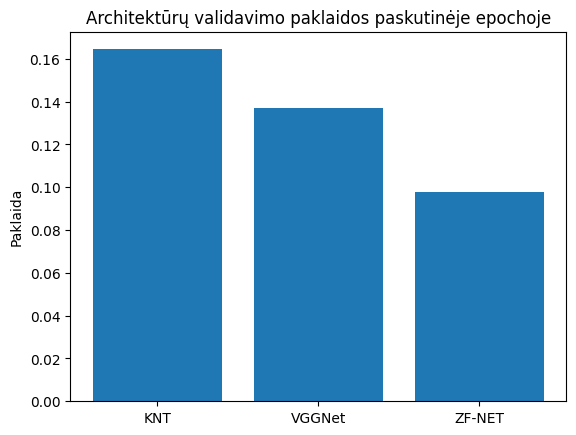

In [18]:
archs = ['KNT', 'VGGNet', 'ZF-NET']

val_losses = [
    history1.history['val_loss'][-1],
    history2.history['val_loss'][-1],
    history3.history['val_loss'][-1]
]

plt.bar(archs, val_losses)
plt.ylabel('Paklaida')
plt.title('Architektūrų validavimo paklaidos paskutinėje epochoje')

plt.savefig('arch_losses.png', dpi=1000)

In [20]:
import pandas as pd

In [22]:
print(
pd.DataFrame({
    'Architektūra': archs,
    'Paklaida': val_losses
}).to_latex()
)

\begin{tabular}{llr}
\toprule
 & Architektūra & Paklaida \\
\midrule
0 & KNT & 0.164439 \\
1 & VGGNet & 0.136950 \\
2 & ZF-NET & 0.097655 \\
\bottomrule
\end{tabular}



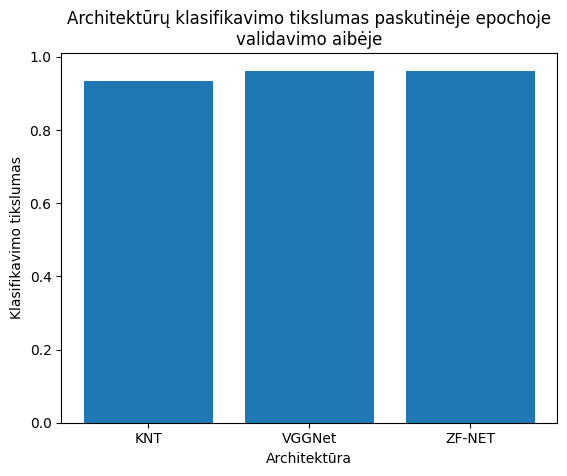

In [23]:
archs = ['KNT', 'VGGNet', 'ZF-NET']

val_acc = [
    history1.history['val_accuracy'][-1],
    history2.history['val_accuracy'][-1],
    history3.history['val_accuracy'][-1]
]

plt.bar(archs, val_acc)
plt.xlabel('Architektūra')
plt.ylabel('Klasifikavimo tikslumas')
plt.title('Architektūrų klasifikavimo tikslumas paskutinėje epochoje\nvalidavimo aibėje')

plt.savefig('arch_accs.png', dpi=1000)

In [28]:
print(
    pd.DataFrame({
    'Architektūra': archs,
    'Paklaida': val_acc
}).to_latex()
)

\begin{tabular}{llr}
\toprule
 & Architektūra & Paklaida \\
\midrule
0 & KNT & 0.934272 \\
1 & VGGNet & 0.962441 \\
2 & ZF-NET & 0.962441 \\
\bottomrule
\end{tabular}



In [6]:
def zf_net(
    train_ds,
    val_ds,
    optimizer,
    dropout = 0.25,
    aktyvacija = "relu",
    batch_norm: bool = True
):

    paslepto_ties_skaicius = 16
    epochs = 20
    
    model_layers3 = [
        layers.Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3), batch_size=BATCH_SIZE),
        layers.Rescaling(1./255)
    ]
    
    model_layers3.extend([
        layers.Conv2D(
            96, 7,
            strides=(2,2),
            padding='same',
            activation=aktyvacija,
            kernel_initializer=initializers.HeNormal()
        ),
        layers.Dropout(dropout)
    ])

    if batch_norm:
        model_layers3.append(layers.BatchNormalization())

    model_layers3.append(layers.MaxPooling2D((3, 3), strides=2))
    
    model_layers3.extend([
        layers.Conv2D(
            256, 3,
            strides=(2,2),
            padding='same',
            activation=aktyvacija,
            kernel_initializer=initializers.HeNormal()
        ),
        layers.Dropout(dropout)
    ])

    if batch_norm:
        model_layers3.append(layers.BatchNormalization())

    model_layers3.append(layers.MaxPooling2D((3, 3), strides=2))
    
    model_layers3.extend([
        layers.Conv2D(
            384, 3,
            strides=(1,1),
            padding='same',
            activation=aktyvacija,
            kernel_initializer=initializers.HeNormal()
        ),
        layers.Dropout(dropout),
        layers.BatchNormalization()
    ])

    if batch_norm:
        model_layers3.append(layers.BatchNormalization())
    
    model_layers3.extend([
        layers.Conv2D(
            384, 3,
            strides=(1,1),
            padding='same',
            activation=aktyvacija,
            kernel_initializer=initializers.HeNormal()
        ),
        layers.Dropout(dropout)
    ])

    if batch_norm:
        model_layers3.append(layers.BatchNormalization())
    
    model_layers3.extend([
        layers.Conv2D(
            256, 3,
            strides=(1,1),
            padding='same',
            activation=aktyvacija,
            kernel_initializer=initializers.HeNormal()
        ),
        layers.Dropout(dropout)
    ])

    if batch_norm:
        model_layers3.append(layers.BatchNormalization())

    model_layers3.append(layers.MaxPooling2D((3, 3), strides=2))

    model_layers3.extend([
        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dense(4096, activation='relu'),
        layers.Dense(N_CLASSES, activation='softmax')
    ])

    loss_func = "sparse_categorical_crossentropy"    
    model3 = keras.Sequential(model_layers3)
    
    model3.compile(
        optimizer=optimizer,
        loss=loss_func,
        metrics=['accuracy']
    )
    
    history3 = model3.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=1
    )

    return history3

In [7]:
lr = 1e-5
history_adam = zf_net(train_ds, val_ds,
    keras.optimizers.Adam(learning_rate=lr),
    dropout = 0.25,
    aktyvacija = "relu",
    batch_norm = True
)

print(history_adam.history['val_loss'][-1])
print(history_adam.history['val_accuracy'][-1])

Epoch 1/20


2025-11-04 22:18:22.118399: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fc864003660 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-04 22:18:22.118427: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2025-11-04 22:18:22.176177: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-04 22:18:22.562252: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-11-04 22:18:23.085561: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3605', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 22:18:23.279486: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas wa

  1/110 ━━━━━━━━━━━━━━━━━━━━ 24:16 13s/step - accuracy: 0.4375 - loss: 1.7628

I0000 00:00:1762287512.031693  201650 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7022 - loss: 0.8044

2025-11-04 22:18:44.130105: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3605', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 22:18:44.432679: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3605', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 22:18:45.641114: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 850.25MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-04 22:18:45.726142: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.24GiB with freed_by_count=0. The caller indicates that th

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.7032 - loss: 0.8015

2025-11-04 22:18:51.829059: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_3', 88 bytes spill stores, 88 bytes spill loads

2025-11-04 22:18:52.876494: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 869.38MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-04 22:18:53.038446: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.27GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-04 22:18:53.145257: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out o

110/110 ━━━━━━━━━━━━━━━━━━━━ 37s 217ms/step - accuracy: 0.8138 - loss: 0.4947 - val_accuracy: 0.3427 - val_loss: 1.3643
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.9412 - loss: 0.1704 - val_accuracy: 0.3521 - val_loss: 1.6777
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.9600 - loss: 0.1140 - val_accuracy: 0.3521 - val_loss: 2.0295
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.9726 - loss: 0.0746 - val_accuracy: 0.3756 - val_loss: 1.7408
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.9714 - loss: 0.0835 - val_accuracy: 0.3521 - val_loss: 1.6102
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.9869 - loss: 0.0431 - val_accuracy: 0.5258 - val_loss: 1.0620
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - accuracy: 0.9817 - loss: 0.0470 - val_accuracy: 0.7512 - val_loss: 0.6285
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - accuracy: 0.9812 - loss: 0.0499 - val

In [9]:
lr = 1e-5
history_sgd = zf_net(train_ds, val_ds,
    keras.optimizers.SGD(learning_rate=lr),
    dropout = 0.25,
    aktyvacija = "relu",
    batch_norm = True
)

print(history_sgd.history['val_loss'][-1])
print(history_sgd.history['val_accuracy'][-1])

Epoch 1/20


2025-11-04 21:20:30.071964: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fb280015580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-04 21:20:30.071999: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2025-11-04 21:20:30.116680: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-04 21:20:30.279056: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-11-04 21:20:30.831452: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3157', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 21:20:30.832489: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas wa

  2/110 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.4062 - loss: 1.7616  

I0000 00:00:1762284039.843789  168132 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3644 - loss: 1.3820

2025-11-04 21:20:49.297145: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3157', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 21:20:49.711121: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3157', 8 bytes spill stores, 8 bytes spill loads



110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.3647 - loss: 1.3808

2025-11-04 21:20:57.127725: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_3', 88 bytes spill stores, 88 bytes spill loads

2025-11-04 21:20:59.850369: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_231', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 21:21:00.163509: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_231', 8 bytes spill stores, 8 bytes spill loads



110/110 ━━━━━━━━━━━━━━━━━━━━ 33s 198ms/step - accuracy: 0.3981 - loss: 1.2402 - val_accuracy: 0.2911 - val_loss: 1.1101
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.4872 - loss: 1.0620 - val_accuracy: 0.3286 - val_loss: 1.1160
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.5734 - loss: 0.9454 - val_accuracy: 0.3662 - val_loss: 1.1180
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.6071 - loss: 0.8663 - val_accuracy: 0.4225 - val_loss: 1.1123
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.6722 - loss: 0.7829 - val_accuracy: 0.4601 - val_loss: 1.0422
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.6848 - loss: 0.7462 - val_accuracy: 0.5352 - val_loss: 0.9340
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.7019 - loss: 0.7033 - val_accuracy: 0.6573 - val_loss: 0.8825
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - accuracy: 0.7162 - loss: 0.6774 - val_accuracy: 0

In [8]:
lr = 1e-5
history_rmsprop = zf_net(train_ds, val_ds,
    keras.optimizers.RMSprop(learning_rate=lr),
    dropout = 0.25,
    aktyvacija = "relu",
    batch_norm = True
)

print(history_rmsprop.history['val_loss'][-1])
print(history_rmsprop.history['val_accuracy'][-1])

Epoch 1/20


2025-11-04 21:25:39.824017: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f7cf8002b70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-04 21:25:39.824035: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2025-11-04 21:25:39.874300: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-04 21:25:40.113696: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-11-04 21:25:40.739245: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3269', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 21:25:41.052861: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas wa

  1/110 ━━━━━━━━━━━━━━━━━━━━ 22:12 12s/step - accuracy: 0.5000 - loss: 1.2268

I0000 00:00:1762284349.606811  169923 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6390 - loss: 1.5136

2025-11-04 21:26:00.297823: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3269', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 21:26:00.506507: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3269', 8 bytes spill stores, 8 bytes spill loads



110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.6402 - loss: 1.5071

2025-11-04 21:26:08.664243: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_3', 88 bytes spill stores, 88 bytes spill loads

2025-11-04 21:26:11.333975: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_231', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 21:26:11.383825: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_231', 8 bytes spill stores, 8 bytes spill loads



110/110 ━━━━━━━━━━━━━━━━━━━━ 35s 213ms/step - accuracy: 0.7681 - loss: 0.8022 - val_accuracy: 0.3427 - val_loss: 1.1915
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.9132 - loss: 0.2548 - val_accuracy: 0.3521 - val_loss: 1.6080
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.9480 - loss: 0.1667 - val_accuracy: 0.3521 - val_loss: 1.9689
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.9663 - loss: 0.1131 - val_accuracy: 0.3756 - val_loss: 1.9183
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.9703 - loss: 0.0818 - val_accuracy: 0.4131 - val_loss: 1.4287
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.9794 - loss: 0.0561 - val_accuracy: 0.5399 - val_loss: 1.2231
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.9783 - loss: 0.0650 - val_accuracy: 0.7559 - val_loss: 0.7333
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.9926 - loss: 0.0280 - val_accura

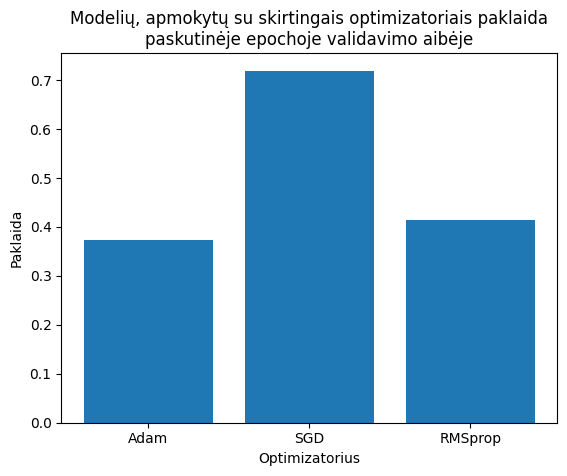

In [10]:
final_val_loss = [0.373001, 0.719278, 0.413285]
opts = ['Adam', 'SGD', 'RMSprop']


plt.bar(opts, final_val_loss)
plt.xlabel('Optimizatorius')
plt.ylabel('Paklaida')
plt.title('Modelių, apmokytų su skirtingais optimizatoriais paklaida\npaskutinėje epochoje validavimo aibėje')


plt.savefig('opt_loss.png', dpi=1000)

In [ ]:
print(
pd.DataFrame({
    'Optimizavimo algoritmas': archs,
    'Paklaida': final_val_loss
}).to_latex().replace('.', ',')
)

In [8]:
dropouts = [0, 0.2, 0.4]
lr = 1e-5

history_drop00 = zf_net(train_ds, val_ds,
        keras.optimizers.Adam(learning_rate=lr),
        dropout = 0,
        aktyvacija = "relu",
        batch_norm = True
)

Epoch 1/20


2025-11-04 21:39:49.585063: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fb74c01e1a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-04 21:39:49.585081: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2025-11-04 21:39:49.635265: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-04 21:39:49.980978: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-11-04 21:39:50.371903: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1763', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 21:39:50.636598: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas wa

  1/110 ━━━━━━━━━━━━━━━━━━━━ 21:26 12s/step - accuracy: 0.1250 - loss: 1.2778

I0000 00:00:1762285198.113365  182239 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8150 - loss: 0.4346

2025-11-04 21:40:09.386020: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1763', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 21:40:09.675781: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1763', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 21:40:11.039478: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 850.25MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-04 21:40:11.124854: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.24GiB with freed_by_count=0. The caller indicates that th

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8160 - loss: 0.4327

2025-11-04 21:40:14.894544: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_4', 36 bytes spill stores, 36 bytes spill loads

2025-11-04 21:40:15.909553: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 869.38MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-04 21:40:16.105274: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.27GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-04 21:40:16.213185: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out o

110/110 ━━━━━━━━━━━━━━━━━━━━ 33s 190ms/step - accuracy: 0.9178 - loss: 0.2240 - val_accuracy: 0.3427 - val_loss: 1.3143
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.9949 - loss: 0.0245 - val_accuracy: 0.3568 - val_loss: 1.8386
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.9994 - loss: 0.0063 - val_accuracy: 0.5164 - val_loss: 1.1193
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 0.9989 - loss: 0.0050 - val_accuracy: 0.8967 - val_loss: 0.3060
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9765 - val_loss: 0.0809
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9812 - val_loss: 0.0565
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - accuracy: 1.0000 - loss: 9.5916e-04 - val_accuracy: 0.9812 - val_loss: 0.0543
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 1.0000 - loss: 5.9402e-04 - v

In [10]:
print(history_drop00.history['val_loss'][-1])
print(history_drop00.history['val_accuracy'][-1])

0.05369465798139572
0.9812206625938416


In [7]:
lr = 1e-5

history_drop02 = zf_net(train_ds, val_ds,
        keras.optimizers.Adam(learning_rate=lr),
        dropout = 0.2,
        aktyvacija = "relu",
        batch_norm = True
)

Epoch 1/20


2025-11-04 21:49:41.737906: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fda14008670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-04 21:49:41.737924: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2025-11-04 21:49:41.788354: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-04 21:49:42.189040: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-11-04 21:49:42.739211: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3605', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 21:49:42.810131: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas wa

  1/110 ━━━━━━━━━━━━━━━━━━━━ 24:30 13s/step - accuracy: 0.6250 - loss: 1.5481

I0000 00:00:1762285791.761895  187782 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.6982 - loss: 0.8073

2025-11-04 21:50:03.615859: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3605', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 21:50:03.726395: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3605', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 21:50:05.390318: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 850.25MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-04 21:50:05.475261: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.24GiB with freed_by_count=0. The caller indicates that th

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.6994 - loss: 0.8042

2025-11-04 21:50:11.023143: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_3', 88 bytes spill stores, 88 bytes spill loads

2025-11-04 21:50:12.105086: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 869.38MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-04 21:50:12.299910: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.27GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-04 21:50:12.407674: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out o

110/110 ━━━━━━━━━━━━━━━━━━━━ 37s 213ms/step - accuracy: 0.8281 - loss: 0.4681 - val_accuracy: 0.3427 - val_loss: 1.1783
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.9457 - loss: 0.1607 - val_accuracy: 0.3521 - val_loss: 1.6705
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.9772 - loss: 0.0712 - val_accuracy: 0.3521 - val_loss: 2.2280
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - accuracy: 0.9800 - loss: 0.0626 - val_accuracy: 0.3897 - val_loss: 1.6031
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.9743 - loss: 0.0766 - val_accuracy: 0.4883 - val_loss: 1.3046
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.9897 - loss: 0.0310 - val_accuracy: 0.7277 - val_loss: 0.6772
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.9891 - loss: 0.0332 - val_accuracy: 0.8779 - val_loss: 0.3612
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.9880 - loss: 0.0331 - val

In [8]:
print(history_drop02.history['val_loss'][-1])
print(history_drop02.history['val_accuracy'][-1])

0.22768786549568176
0.9389671087265015


In [7]:
lr = 1e-5

history_drop04 = zf_net(train_ds, val_ds,
        keras.optimizers.Adam(learning_rate=lr),
        dropout = 0.4,
        aktyvacija = "relu",
        batch_norm = True
)

Epoch 1/20


2025-11-04 21:55:28.290354: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f8e1c01b3d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-04 21:55:28.290378: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2025-11-04 21:55:28.342611: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-04 21:55:28.731426: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-11-04 21:55:29.205512: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3605', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 21:55:29.359628: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas wa

  1/110 ━━━━━━━━━━━━━━━━━━━━ 24:37 14s/step - accuracy: 0.2500 - loss: 1.8805

I0000 00:00:1762286138.350440  189575 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.6301 - loss: 1.0016

2025-11-04 21:55:49.915357: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3605', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 21:55:50.216526: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3605', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 21:55:51.555216: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 850.25MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-04 21:55:51.643750: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.24GiB with freed_by_count=0. The caller indicates that th

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.6310 - loss: 0.9992

2025-11-04 21:55:57.095529: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_3', 88 bytes spill stores, 88 bytes spill loads

2025-11-04 21:55:58.119286: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 869.38MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-04 21:55:58.271446: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.27GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-04 21:55:58.378996: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out o

110/110 ━━━━━━━━━━━━━━━━━━━━ 36s 208ms/step - accuracy: 0.7276 - loss: 0.7391 - val_accuracy: 0.3427 - val_loss: 1.1304
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.8561 - loss: 0.3913 - val_accuracy: 0.3521 - val_loss: 1.1892
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - accuracy: 0.9063 - loss: 0.2718 - val_accuracy: 0.3521 - val_loss: 1.2314
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.9383 - loss: 0.1873 - val_accuracy: 0.3756 - val_loss: 1.2006
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.9229 - loss: 0.2130 - val_accuracy: 0.3521 - val_loss: 1.2765
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.9600 - loss: 0.1258 - val_accuracy: 0.4225 - val_loss: 1.1853
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.9543 - loss: 0.1156 - val_accuracy: 0.5164 - val_loss: 1.0990
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.9657 - loss: 0.1053 - val

In [8]:
print(history_drop04.history['val_loss'][-1])
print(history_drop04.history['val_accuracy'][-1])

1.0778924226760864
0.5633803009986877


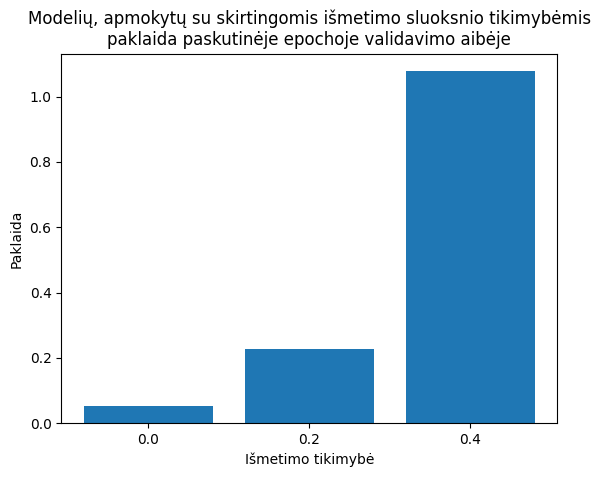

In [10]:
drop_val_acc = [0.053694, 0.227687, 1.07789]

plt.bar( ['0.0', '0.2', '0.4'], drop_val_acc)
plt.xlabel('Išmetimo tikimybė')
plt.ylabel('Paklaida')
plt.title('Modelių, apmokytų su skirtingomis išmetimo sluoksnio tikimybėmis\npaklaida paskutinėje epochoje validavimo aibėje')

plt.savefig('drop_accs.png', dpi=1000)

In [ ]:
pd.DataFrame({
    'Optimizavimo algoritmas': archs,
    'Paklaida': final_val_loss
}).to_latex()

In [ ]:
lr = 1e-5

history_batch = zf_net(train_ds, val_ds,
    keras.optimizers.Adam(learning_rate=lr),
    dropout = 0.0,
    aktyvacija = "relu",
    batch_norm = True
)

In [ ]:
lr = 1e-5

history_no_batch = zf_net(train_ds, val_ds,
    keras.optimizers.Adam(learning_rate=lr),
    dropout = 0.0,
    aktyvacija = "relu",
    batch_norm = False
)

In [ ]:
batch_val_acc = [hist.history['val_loss'][-1] 
                 for hist in [history_batch, history_no_batch] ]

plt.bar( ['Taikytas', 'Netaikytas'], batch_val_acc)
plt.xlabel('Paketo normalizavimas')
plt.ylabel('Paklaida')
plt.title('Modelių, apmokytų su ir be paketo normalizacijos sluoksnio\npaklaida paskutinėje epochoje validavimo aibėje')

plt.savefig('batch_loss.png', dpi=1000)

In [ ]:
pd.DataFrame({
    'Paketo normalizavimas': ['Taikytas', 'Netaikytas'],
    'Paklaida': batch_val_loss
}).to_latex()

In [ ]:
lr = 1e-5
history_relu = zf_net(train_ds, val_ds,
    keras.optimizers.Adam(learning_rate=lr),
    dropout = 0.0,
    aktyvacija = "relu",
    batch_norm = True
)

history_sigmoid = zf_net(train_ds, val_ds,
    keras.optimizers.SGD(learning_rate=lr),
    dropout = 0.0,
    aktyvacija = "sigmoid",
    batch_norm = False
)

history_tanh = zf_net(train_ds, val_ds,
    keras.optimizers.SGD(learning_rate=lr),
    dropout = 0.0,
    aktyvacija = "tanh",
    batch_norm = False
)

In [ ]:
histories = [history_relu, history_sigmoid, history_tanh]
act_loss = [hist.history['val_loss'][-1] for hist in histories]

plt.bar( ['ReLU', 'Sigmoid', 'Hiperbolinis\ntangentas'], act_loss)
plt.xlabel('Aktyvacijos funkcija')
plt.ylabel('Paklaida')
plt.title('Modelių, apmokytų su ir be paketo normalizacijos sluoksnio\npaklaida paskutinėje epochoje validavimo aibėje')

plt.savefig('act_loss.png', dpi=500)

In [ ]:
pd.DataFrame({
    'Aktyvacijos funkcija': ['ReLU', 'Sigmoid', 'Hiperbolinis\ntangentas'],
    'Paklaida': act_loss
}).to_latex()

In [7]:
def zf_net_model(
    train_ds,
    val_ds,
    optimizer,
    dropout = 0.25,
    aktyvacija = "relu",
    batch_norm: bool = True
):

    paslepto_ties_skaicius = 16
    epochs = 20
    
    model_layers3 = [
        layers.Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3), batch_size=BATCH_SIZE),
        layers.Rescaling(1./255)
    ]
    
    model_layers3.extend([
        layers.Conv2D(
            96, 7,
            strides=(2,2),
            padding='same',
            activation=aktyvacija,
            kernel_initializer=initializers.HeNormal()
        ),
        layers.Dropout(dropout)
    ])

    if batch_norm:
        model_layers3.append(layers.BatchNormalization())

    model_layers3.append(layers.MaxPooling2D((3, 3), strides=2))
    
    model_layers3.extend([
        layers.Conv2D(
            256, 3,
            strides=(2,2),
            padding='same',
            activation=aktyvacija,
            kernel_initializer=initializers.HeNormal()
        ),
        layers.Dropout(dropout)
    ])

    if batch_norm:
        model_layers3.append(layers.BatchNormalization())

    model_layers3.append(layers.MaxPooling2D((3, 3), strides=2))
    
    model_layers3.extend([
        layers.Conv2D(
            384, 3,
            strides=(1,1),
            padding='same',
            activation=aktyvacija,
            kernel_initializer=initializers.HeNormal()
        ),
        layers.Dropout(dropout),
        layers.BatchNormalization()
    ])

    if batch_norm:
        model_layers3.append(layers.BatchNormalization())
    
    model_layers3.extend([
        layers.Conv2D(
            384, 3,
            strides=(1,1),
            padding='same',
            activation=aktyvacija,
            kernel_initializer=initializers.HeNormal()
        ),
        layers.Dropout(dropout)
    ])

    if batch_norm:
        model_layers3.append(layers.BatchNormalization())
    
    model_layers3.extend([
        layers.Conv2D(
            256, 3,
            strides=(1,1),
            padding='same',
            activation=aktyvacija,
            kernel_initializer=initializers.HeNormal()
        ),
        layers.Dropout(dropout)
    ])

    if batch_norm:
        model_layers3.append(layers.BatchNormalization())

    model_layers3.append(layers.MaxPooling2D((3, 3), strides=2))

    model_layers3.extend([
        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dense(4096, activation='relu'),
        layers.Dense(N_CLASSES, activation='softmax')
    ])

    loss_func = "sparse_categorical_crossentropy"    
    model3 = keras.Sequential(model_layers3)
    
    model3.compile(
        optimizer=optimizer,
        loss=loss_func,
        metrics=['accuracy']
    )
    
    history3 = model3.fit(
        train_ds,
        validation_data=val_ds,
        callbacks=[ keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3) ],
        epochs=epochs,
        verbose=1
    )

    return model3, history3

In [8]:
model_final, history_final = zf_net_model(
    train_ds, val_ds,
    keras.optimizers.Adam(learning_rate=1e-5),
    dropout = 0.0,
    aktyvacija = "relu",
    batch_norm = True
)

Epoch 1/20


2025-11-04 22:26:47.669946: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f1368003360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-04 22:26:47.669960: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2025-11-04 22:26:47.715434: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-04 22:26:48.039727: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-11-04 22:26:48.472227: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1763', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 22:26:48.773156: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas wa

  1/110 ━━━━━━━━━━━━━━━━━━━━ 21:03 12s/step - accuracy: 0.2500 - loss: 1.4890

I0000 00:00:1762288016.057082  203437 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8049 - loss: 0.4800

2025-11-04 22:27:06.772919: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1763', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 22:27:07.101714: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1763', 8 bytes spill stores, 8 bytes spill loads

2025-11-04 22:27:08.570928: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 850.25MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-04 22:27:08.655969: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.24GiB with freed_by_count=0. The caller indicates that th

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.8059 - loss: 0.4778

2025-11-04 22:27:12.411141: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_4', 36 bytes spill stores, 36 bytes spill loads

2025-11-04 22:27:13.395907: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 869.38MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-04 22:27:13.546810: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.27GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-04 22:27:13.654145: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out o

110/110 ━━━━━━━━━━━━━━━━━━━━ 32s 185ms/step - accuracy: 0.9109 - loss: 0.2398 - val_accuracy: 0.3521 - val_loss: 1.1542
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.9880 - loss: 0.0372 - val_accuracy: 0.4883 - val_loss: 1.2479
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.9977 - loss: 0.0103 - val_accuracy: 0.6714 - val_loss: 0.7523
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.9202 - val_loss: 0.2578
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.9718 - val_loss: 0.1059
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.9994 - loss: 0.0031 - val_accuracy: 0.9671 - val_loss: 0.0864
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9765 - val_loss: 0.0690
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 1.0000 - loss: 6.1464e-04 - val_ac

In [9]:
def gauti_tiksluma(modelis):
    return modelis.evaluate(test_ds)[1]

In [10]:
from sklearn.metrics import confusion_matrix

In [11]:
def evaluate_data(modelis, test_df):
    data_iterator = test_df.as_numpy_iterator()
    
    y_pred_all = []
    y_test_all = []
    
    for test_x, test_y in data_iterator:
    
        # Praleisti paskutini nepilna paketa
        if test_x.shape[0] < BATCH_SIZE:
            continue

        y_pred = modelis.predict( test_x, verbose=0 )
    
        y_test_all.append( test_y )
        y_pred_all.append( y_pred )

    y_pred = np.argmax( np.concat( y_pred_all ), axis=-1)
    y_test = np.concat(y_test_all)

    accuracy = np.mean( y_pred == y_test )
    conf_mat = confusion_matrix( y_test, y_pred )

    return accuracy, conf_mat

In [12]:
acc, conf_mat = evaluate_data(model_final, train_ds)

2025-11-04 22:29:12.136191: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [13]:
pd.DataFrame({
    'Duomenų aibė': ['Mokymo', 'Validavimo', 'Testavimo'],
    'Klasifikavimo tikslumas': [
        history_final.history['accuracy'],
        history_final.history['val_accuracy'],
        acc
    ]
}).to_latex()

NameError: name 'pd' is not defined

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
def plot_conf_mat(conf_mat):
    fig, ax = plt.subplots()

    display = ConfusionMatrixDisplay( conf_mat, display_labels=['Popierius', 'Akmuo', 'Žirklės'] )
    
    display.plot(ax=ax)
    
    ax.set_xlabel('Išvestis')
    ax.set_ylabel('Tikroji reikšmė')
    ax.set_title('ZF-Net architektūros klasifikavimo matrica')
    
    plt.savefig('arch1_conf_mat.png', dpi=1000)

plot_conf_mat(conf_mat)